<a href="https://colab.research.google.com/github/PabloShol/simulacion2/blob/main/Cadenas%20de%201%20y%200.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métodos para obtener variables aleatorias

### TRANSFORMADA INVERSA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)
print("Entorno configurado correctamente")

Entorno configurado correctamente


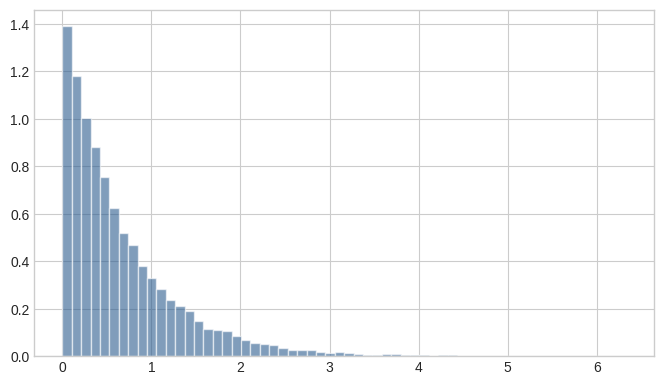

In [ ]:
# Transformada inversa
def transformada_inversa_exponencial(lam=1.0, size=1000):
  u = np.random.uniform(0,1,size)
  return -np.log(1-u)/lam

#Parametros y generacion
lam = 1.5
n = 20000
datos_exp = transformada_inversa_exponencial(lam=lam,size=n)

#Grafica
plt.figure(figsize=(8,4.5))
count, bins, _ = plt.hist(datos_exp, bins=60, density=True, alpha=0.6, color='#2b5c8f', edgecolor='white', label = "Muestras Simulada")
plt.show()


# Metodo Metropolis-hastings

Ejercicio: Use el algoritmo Metroplis-Hastings para simular la función:
  $$f(x) = C e^{-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2}}$$

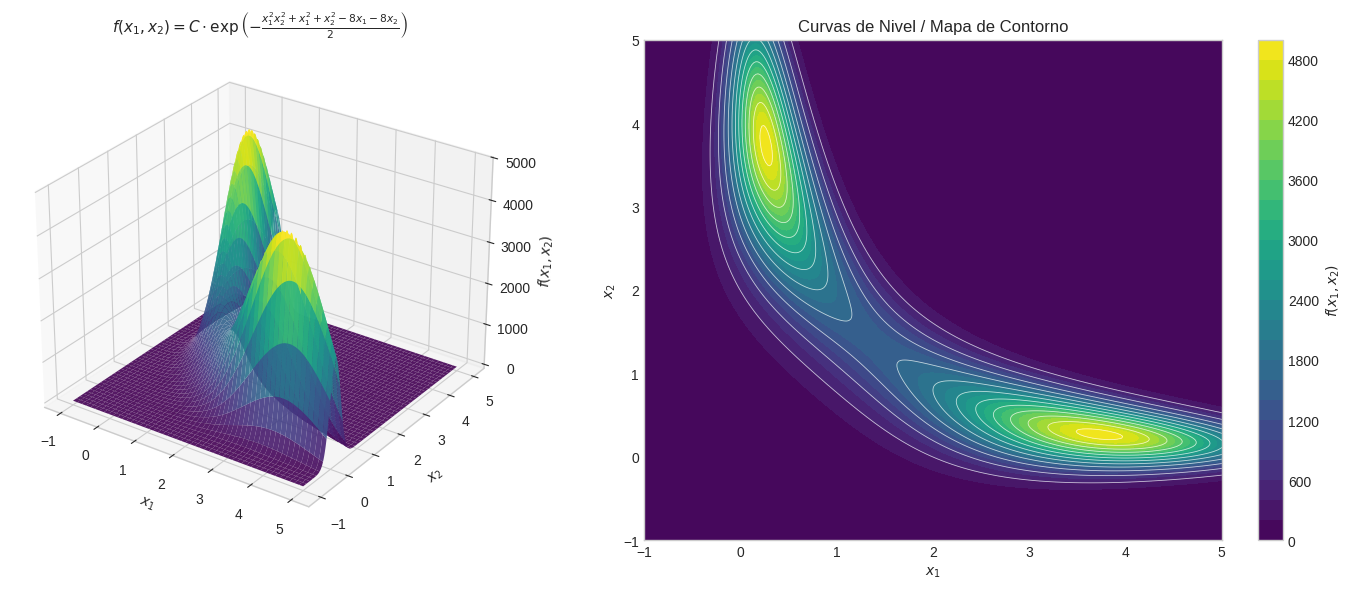

In [ ]:
# Grafica de la funcion
import numpy as np
import matplotlib.pyplot as plt

# Definir la cuadrícula en R^2
x1 = np.linspace(-1, 5, 300)
x2 = np.linspace(-1, 5, 300)
X1, X2 = np.meshgrid(x1, x2)

# Exponente: -(x1^2 * x2^2 + x1^2 + x2^2 - 8*x1 - 8*x2) / 2
exponente = -0.5 * (X1**2 * X2**2 + X1**2 + X2**2 - 8.0 * X1 - 8.0 * X2)
# Con C = 1 (forma proporcional de la función)
Z = np.exp(exponente)

# Configurar visualización (Superficie 3D y Mapa de Contornos)
fig = plt.figure(figsize=(15, 6))

# 1. Gráfica de Superficie en 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title(r'$f(x_1, x_2) = C \cdot \exp\left(-\frac{x_1^2 x_2^2 + x_1^2 + x_2^2 - 8x_1 - 8x_2}{2}\right)$', fontsize=11)
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.view_init(elev=28, azim=-55)

# 2. Mapa de Calor y Curvas de Nivel (Contorno 2D)
ax2 = fig.add_subplot(1, 2, 2)
contour_fill = ax2.contourf(X1, X2, Z, levels=30, cmap='viridis')
ax2.contour(X1, X2, Z, levels=12, colors='white', linewidths=0.6, alpha=0.7)
cbar = fig.colorbar(contour_fill, ax=ax2)
cbar.set_label('$f(x_1, x_2)$')
ax2.set_title('Curvas de Nivel / Mapa de Contorno', fontsize=12)
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
C = 1.0 / 20216.335877

def f(x):
  x1, x2 = x[0], x[1]
  exponente = -0.5 * (x1**2 * x2**2 + x1**2 + x2**2 - 8.0 * x1 - 8.0 * x2)
  return C * np.exp(exponente)

def alpha(xt, y):
  log_f_y = -0.5 * (y[0]**2 * y[1]**2 + y[0]**2 + y[1]**2 - 8.0 * y[0] - 8.0 * y[1])
  log_f_xt = -0.5 * (xt[0]**2 * xt[1]**2 + xt[0]**2 + xt[1]**2 - 8.0 * xt[0] - 8.0 * xt[1])
  log_ratio = log_f_y - log_f_xt

  if log_ratio >= 0:
    return 1.0
    return float(np.exp(log_ratio))

# -------------------------------------------------------------------------
# Ejecución del Pseudocódigo
# -------------------------------------------------------------------------
N = 50000  # Tamaño total de la muestra deseado
X = np.empty((N, 2))

# Paso 1: Inicializar X_1 = (x1, x2) y hacer t = 1 (índice 0 en Python)
X[0] = np.array([0.0, 0.0])
t = 0  # t representa el índice actual (de 0 a N-2)

# Bucle (Pasos 2 a 4)
while t < N - 1:
# 2. Generar Z1, Z2 ~ N(0, 1) independientemente
  Z = np.random.normal(loc=0.0, scale=1.0, size=2)
  Y = X[t] + Z

# Calcular alpha = alpha(X_t, Y)
  a = alpha(X[t], Y)

# 3. Generar U ~ U[0, 1]. Si U < alpha, X_{t+1} = Y; otro caso, X_{t+1} = X_t
  U = np.random.uniform(0.0, 1.0)
if U < a:
  X[t + 1] = Y
else:
  X[t + 1] = X[t]

# 4. Incrementar t
t += 1

# Descartar las primeras iteraciones (burn-in)
burn_in = 5000
muestras = X[burn_in:]
# -------------------------------------------------------------------------
# Gráficas 3D y 2D (con la trayectoria/muestras superpuestas)
# -------------------------------------------------------------------------
x1_grid = np.linspace(-1, 5, 200)
x2_grid = np.linspace(-1, 5, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z_teorica = f([X1, X2])

fig = plt.figure(figsize=(16, 6))

# 1. Gráfica 3D: Superficie teórica de f(x)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z_teorica, cmap='viridis', edgecolor='none', alpha=0.85)
ax1.set_title(r'Superficie 3D: $f(x_1, x_2)$ con $C = 1/20216.335877$', fontsize=11, fontweight='bold')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.view_init(elev=28, azim=-55)

# 2. Gráfica 2D: Curvas de nivel teóricas con la caminata aleatoria superpuesta
ax2 = fig.add_subplot(1, 2, 2)
contour_fill = ax2.contourf(X1, X2, Z_teorica, levels=25, cmap='viridis', alpha=0.8)
cbar = fig.colorbar(contour_fill, ax=ax2)
cbar.set_label('$f(x_1, x_2)$')

# Superponer las muestras simuladas por la caminata aleatoria
ax2.scatter(muestras[::5, 0], muestras[::5, 1], s=2, color='#e76f51', alpha=0.3, label='Puntos Caminata ($X_t$)')
# Trazar un tramo de la trayectoria consecutiva
ax2.plot(muestras[:150, 0], muestras[:150, 1], color='white', lw=0.7, alpha=0.8, label='Trayectoria (primeros 150 pasos)')

ax2.set_title('Contorno 2D y Caminata Aleatoria', fontsize=12, fontweight='bold')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


In [2]:
import numpy as np
import random

def es_buena(cadena):
  return "11" not in cadena

def guardar_buenas(m):
  buenas = []
  for i in range(2**m):
    cadena = format(i, f'0{m}b')
    if es_buena(cadena):
      buenas.append(cadena)
  return buenas

def simular(m, N):
  buenas = guardar_buenas(m)
  resultados = []

  for _ in range(N):
    cadena = random.choice(buenas)
    numero_unos = cadena.count("1")
    resultados.append(numero_unos)
  return np.mean(resultados)

N = 4
m = 10000

estimacion = simular(m, N)
print("Numero de simulaciones:", N)
print("Numero esperado:", estimacion)

KeyboardInterrupt: 